In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy
from scipy import constants as cons


In [12]:
c = 2.99792458e10  # cm/s
Msun = 1.989e33  # g
day = 24*3600  # s
pi = 3.14159265359
tau_Ni = 8.8*day  # s
tau_Co = 111.3*day  # s
e_Ni = 3.9e10  # erg/s/g
e_Co = 6.78e9  # erg/s/g

pc = 3.26156378*(cons.light_year)
Mej = 10*Msun    # mass of ejecta
M_Ni= 0.1*Msun   # mass of 56Ni
Rmax0 = 1e14 # cm
Ek = 1*1e51 # erg
kappa = 0.2  # cm^2/g
x0 = 0.1
delta = 0
n = 10
Im = x0**3/(3-delta)+(x0**n-x0**3)/(3-n)
Ik = x0**5/(5-delta)+(x0**n-x0**5)/(5-n)
rho0 = Mej/(4*pi*Im*Rmax0**3)  # g/cm^3
v_max = (2*Ek*Im/(Mej*Ik))**(1/2)   # cm/s
beta = 13.8
tau_m = (2*kappa*Mej/(beta*c*v_max))**(1/2)

In [8]:
def L_rad(t):     ## Ni衰变释放光度 
    return M_Ni*((e_Ni-e_Co)*np.exp(-t/tau_Ni) + e_Co*np.exp(-t/tau_Co))

L_Ni0 = M_Ni*(e_Ni-e_Co)
y = tau_m/tau_Ni
z = tau_m/tau_Co

def f_quad(xp):
    return xp*np.exp(xp*xp/2.0)*(np.exp(-xp*y) + e_Co/(e_Ni-e_Co) * np.exp(-xp*z) )

def Lamd_x(x):
    return np.exp(-x*x/2.0)*scipy.integrate.quad(f_quad,0,x)[0]

def L_bol(t):
    x = t/tau_m
    return L_Ni0*Lamd_x(x)

L_bol_vel = np.vectorize(L_bol)

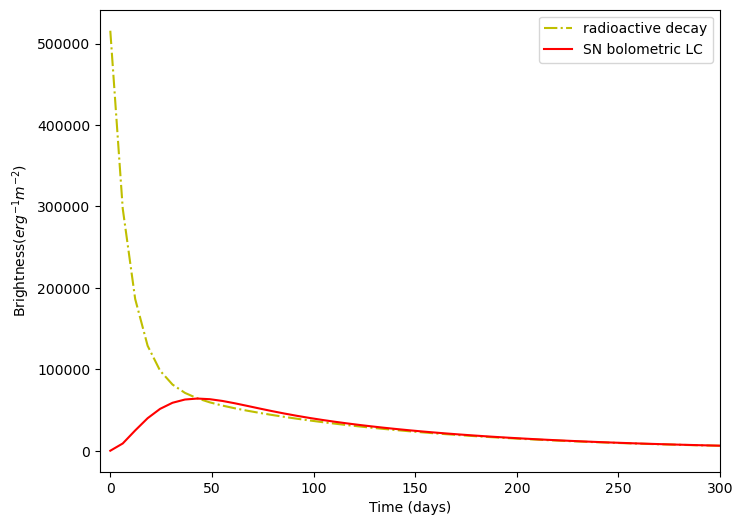

In [25]:
t_s = np.linspace(0,300)*day
fig = plt.figure(figsize=(8, 6))

def E_earth(L):
    return L/(4*pi*10*pc)**2

plt.plot(t_s/day, E_earth(L_rad(t_s)),'y-.', label='radioactive decay')
plt.plot(t_s/day, E_earth(L_bol_vel(t_s)),'r-', label='SN bolometric LC')

plt.xlabel('Time (days)')
plt.ylabel(r'Brightness($erg^{-1}m^{-2}$)')
plt.legend()

plt.xlim(-5, 300)

plt.show()